# IronKaggle 🏆 — Sales Prediction

**Goal:** predict daily store sales using historical data.

This is a regression problem — `Sales` is our continuous target variable.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Data

In [2]:
df = pd.read_csv("sales.csv")
df.head()

,True_index,Store_ID,Day_of_week,Date,Nb_customers_on_day,Open,Promotion,State_holiday,School_holiday,Sales
0,0,625,3,2013-11-06,641,1,1,0,0,7293
1,1,293,2,2013-07-16,877,1,1,0,1,7060
2,2,39,4,2014-01-23,561,1,1,0,0,4565
3,3,676,4,2013-09-26,1584,1,1,0,0,6380
4,4,709,3,2014-01-22,1477,1,1,0,0,11647


In [3]:
df.shape

(640840, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   True_index           640840 non-null  int64 
 1   Store_ID             640840 non-null  int64 
 2   Day_of_week          640840 non-null  int64 
 3   Date                 640840 non-null  object
 4   Nb_customers_on_day  640840 non-null  int64 
 5   Open                 640840 non-null  int64 
 6   Promotion            640840 non-null  int64 
 7   State_holiday        640840 non-null  object
 8   School_holiday       640840 non-null  int64 
 9   Sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [5]:
df.describe()

,True_index,Store_ID,Day_of_week,Nb_customers_on_day,Open,Promotion,School_holiday,Sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [6]:
# any missing values?
df.isnull().sum()

True_index             0
Store_ID               0
Day_of_week            0
Date                   0
Nb_customers_on_day    0
Open                   0
Promotion              0
State_holiday          0
School_holiday         0
Sales                  0
dtype: int64

In [7]:
# any duplicates?
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

Let's get a feel for the data before touching any models.

### 3.1 Standardise column names

In [8]:
df.columns = df.columns.str.lower()

df = df.rename(columns={
    "day_of_the_week":     "day_of_week",
    "number_of_customers": "nb_customers",
    "nb_customers_on_day": "nb_customers",
})

print(df.columns.tolist())

['true_index', 'store_id', 'day_of_week', 'date', 'nb_customers', 'open', 'promotion', 'state_holiday', 'school_holiday', 'sales']


### 3.2 Target variable — Sales

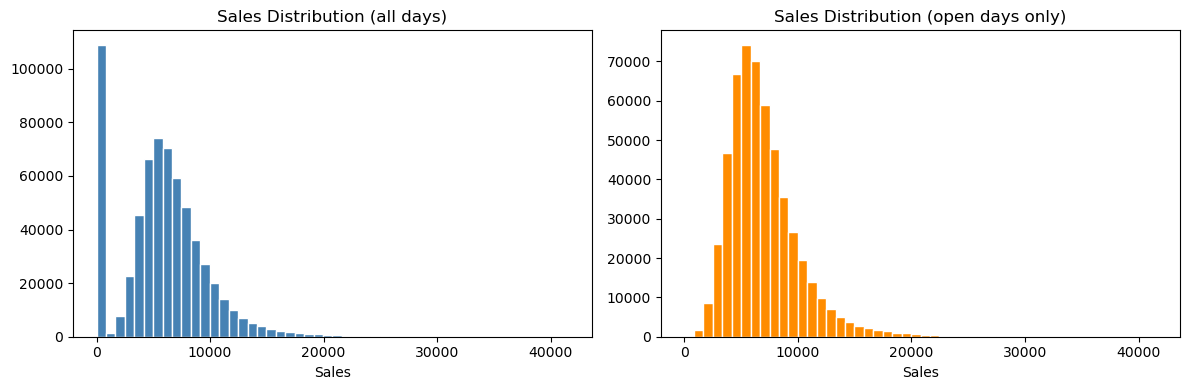

In [9]:
# Sales when the shop is closed is always 0, so let's look at both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Sales Distribution (all days)")
axes[0].set_xlabel("Sales")

axes[1].hist(df[df['sales'] > 0]['sales'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title("Sales Distribution (open days only)")
axes[1].set_xlabel("Sales")

plt.tight_layout()
plt.show()

In [10]:
df['sales'].describe()

count    640840.000000
mean       5777.469011
std        3851.338083
min           0.000000
25%        3731.000000
50%        5746.000000
75%        7860.000000
max       41551.000000
Name: sales, dtype: float64

### 3.3 Numerical features

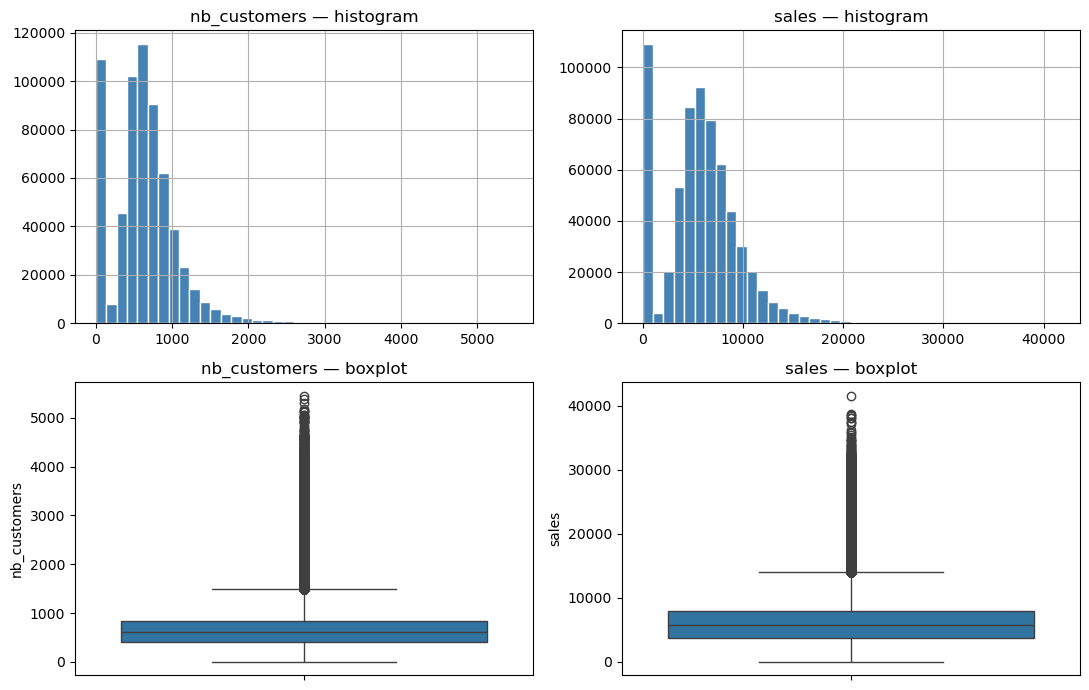

In [11]:
num_cols = ['nb_customers', 'sales']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[0][i], bins=40, color='steelblue', edgecolor='white')
    axes[0][i].set_title(f"{col} — histogram")
    
    sns.boxplot(y=df[col], ax=axes[1][i])
    axes[1][i].set_title(f"{col} — boxplot")

plt.tight_layout()
plt.show()

### 3.4 Categorical / binary features

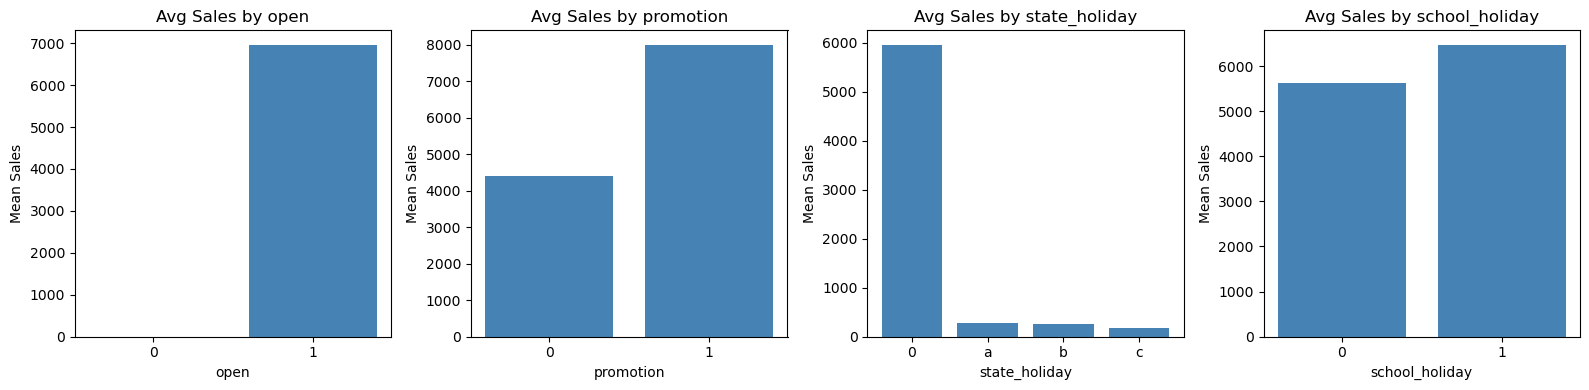

In [12]:
# How does the average sales change across each binary/categorical column?
cat_cols = ['open', 'promotion', 'state_holiday', 'school_holiday']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cat_cols):
    grouped = df.groupby(col)['sales'].mean().reset_index()
    axes[i].bar(grouped[col].astype(str), grouped['sales'], color='steelblue')
    axes[i].set_title(f"Avg Sales by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Mean Sales")

plt.tight_layout()
plt.show()

In [13]:
# Important: when a shop is closed, sales are ALWAYS 0
# We can use this as a hard rule at prediction time
print("Open=0 sales stats:")
print(df[df['open'] == 0]['sales'].describe())
print()
print("Open=1 sales stats:")
print(df[df['open'] == 1]['sales'].describe())

Open=0 sales stats:
count    108824.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: sales, dtype: float64

Open=1 sales stats:
count    532016.000000
mean       6959.251679
std        3105.241710
min           0.000000
25%        4861.000000
50%        6372.000000
75%        8365.000000
max       41551.000000
Name: sales, dtype: float64


### 3.5 Correlation Heatmap

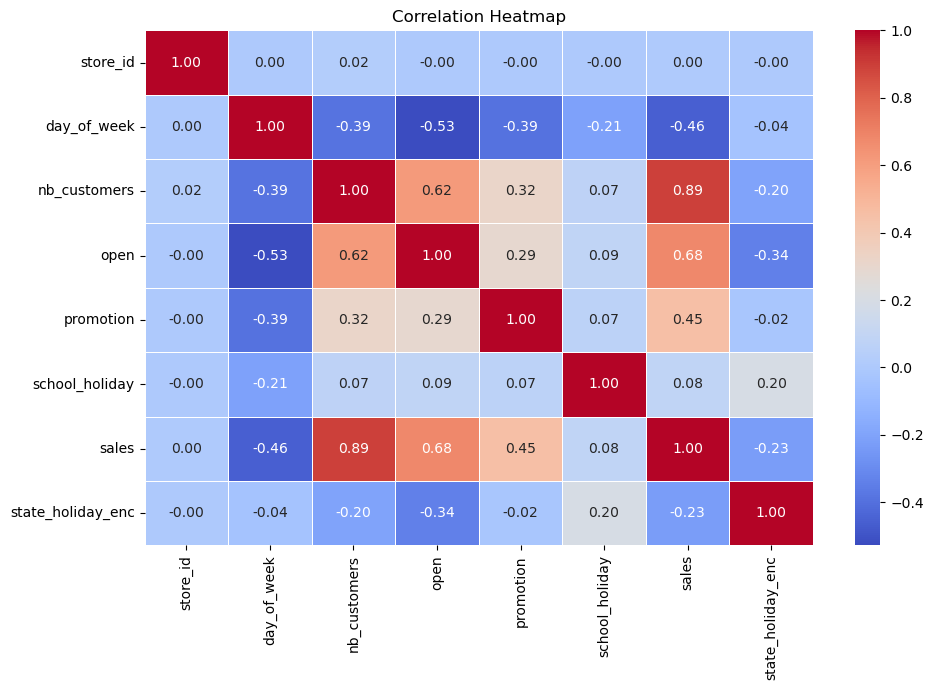

In [14]:
df_encoded = df.copy()
holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
df_encoded['state_holiday_enc'] = df_encoded['state_holiday'].map(holiday_map).fillna(0)
df_encoded = df_encoded.drop(columns=['state_holiday', 'true_index', 'date'], errors='ignore')

plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

Let's extract more signal from the `date` column and create some interaction features.

In [15]:
def feature_engineer(df):
    df = df.copy()
    
    # --- date features ---
    df['date'] = pd.to_datetime(df['date'])
    df['year']           = df['date'].dt.year
    df['month']          = df['date'].dt.month
    df['day']            = df['date'].dt.day
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']     = (df['day_of_week'] >= 6).astype(int)
    df['is_month_start'] = (df['day'] <= 5).astype(int)
    df['is_month_end']   = (df['day'] >= 25).astype(int)

    # --- encode state_holiday ---
    holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
    df['state_holiday_enc'] = df['state_holiday'].map(holiday_map).fillna(0)

    # --- interaction features ---
    # customers on a promo day / open day might behave differently
    df['customers_x_promo'] = df['nb_customers'] * df['promotion']
    df['customers_x_open']  = df['nb_customers'] * df['open']
    df['open_x_promo']      = df['open'] * df['promotion']

    df = df.drop(columns=['date', 'state_holiday', 'true_index'], errors='ignore')
    return df

df_fe = feature_engineer(df)
print("Shape after feature engineering:", df_fe.shape)
df_fe.head()

Shape after feature engineering: (640840, 18)


,store_id,day_of_week,nb_customers,open,promotion,school_holiday,sales,year,month,day,week_of_year,is_weekend,is_month_start,is_month_end,state_holiday_enc,customers_x_promo,customers_x_open,open_x_promo
0,625,3,641,1,1,0,7293,2013,11,6,45,0,0,0,0,641,641,1
1,293,2,877,1,1,1,7060,2013,7,16,29,0,0,0,0,877,877,1
2,39,4,561,1,1,0,4565,2014,1,23,4,0,0,0,0,561,561,1
3,676,4,1584,1,1,0,6380,2013,9,26,39,0,0,1,0,1584,1584,1
4,709,3,1477,1,1,0,11647,2014,1,22,4,0,0,0,0,1477,1477,1


In [16]:
# save cleaned data
df_fe.to_csv("customer_data.csv", index=False)
print("saved!")

saved!


## 5. Model Development

### 5.1 Features & target

In [17]:
df_fe = pd.read_csv("customer_data.csv")

X = df_fe.drop(columns=['sales'])
y = df_fe['sales']

print("Features:", X.columns.tolist())
print("X shape:", X.shape)

Features: ['store_id', 'day_of_week', 'nb_customers', 'open', 'promotion', 'school_holiday', 'year', 'month', 'day', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'state_holiday_enc', 'customers_x_promo', 'customers_x_open', 'open_x_promo']
X shape: (640840, 17)


### 5.2 Train / test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (512672, 17)
Test:  (128168, 17)


### 5.3 Scaling

We fit the scaler **only on the training set** — if we fit on the full dataset we'd be leaking test info into training.

In [19]:
num_cols = [
    'nb_customers', 'store_id', 'day_of_week',
    'year', 'month', 'day', 'week_of_year',
    'customers_x_promo', 'customers_x_open', 'open_x_promo',
    'state_holiday_enc'
]
num_cols = [c for c in num_cols if c in X_train.columns]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

### 5.4 Baseline — Linear Regression

In [20]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Linear Regression")
print("-" * 30)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_base):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):,.0f}")
print(f"R²:   {r2_score(y_test, y_pred_base):.4f}")

Linear Regression
------------------------------
MAE:  973
RMSE: 1,461
R²:   0.8582


### 5.5 Comparing ensemble models

In [ ]:
models = [
    {"name": "Ridge",            "model": Ridge()},
    {"name": "Bagging",          "model": BaggingRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=50, random_state=42)},
    {"name": "RandomForest",     "model": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)},
    {"name": "GradientBoosting", "model": GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)},
    {"name": "XGBoost",          "model": XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                                                        subsample=0.8, colsample_bytree=0.8,
                                                        eval_metric='mae', random_state=42, n_jobs=-1, tree_method='hist')},
]

results = []

for entry in models:
    clf = entry["model"]
    clf.fit(X_train, y_train)
    yp = clf.predict(X_test)
    
    # closed shops always have 0 sales — hard rule
    yp[X_test['open'] == 0] = 0
    yp = np.maximum(yp, 0)

    results.append({
        "Model": entry["name"],
        "MAE":   round(mean_absolute_error(y_test, yp), 2),
        "RMSE":  round(np.sqrt(mean_squared_error(y_test, yp)), 2),
        "R²":    round(r2_score(y_test, yp), 4),
    })
    print(f"{entry['name']} done ✓")

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df

Ridge done ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(results_df['Model'], results_df['MAE'], color='steelblue')
axes[0].set_title("MAE — lower is better")
axes[0].set_xlabel("MAE")
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['R²'], color='darkorange')
axes[1].set_title("R² — higher is better")
axes[1].set_xlabel("R²")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

XGBoost came out on top, so let's tune it with `GridSearchCV`.

We're using `scoring='neg_mean_absolute_error'` and 3-fold CV to keep runtime reasonable.

In [ ]:
models_dict = {entry["name"]: entry["model"] for entry in models}

param_grid = {
    "n_estimators":  [200, 500],
    "max_depth":     [6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(eval_metric='mae', random_state=42, n_jobs=-1, tree_method='hist'),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAE:", round(-grid_search.best_score_, 2))

In [ ]:
best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_pred_tuned[X_test['open'] == 0] = 0
y_pred_tuned = np.maximum(y_pred_tuned, 0)

print("Tuned XGBoost — Test Set")
print("-" * 35)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_tuned):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):,.0f}")
print(f"R²:   {r2_score(y_test, y_pred_tuned):.4f}")

### 6.1 Residual analysis

In [ ]:
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_tuned, residuals, alpha=0.2, s=4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

# ideally residuals should be centered around 0
print("Mean residual:", round(residuals.mean(), 2))

### 6.2 Feature importance

In [ ]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp[:12].values, y=feat_imp[:12].index, palette='viridis')
plt.title("Top 12 Feature Importances — Tuned XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 6.3 Actual vs Predicted

In [ ]:
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_sample = np.array(y_test)[sample_idx]
p_sample = y_pred_tuned[sample_idx]

plt.figure(figsize=(7, 6))
plt.scatter(y_sample, p_sample, alpha=0.4, s=15, color='steelblue')
max_val = max(y_sample.max(), p_sample.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (500 samples)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Final Model Comparison

In [ ]:
final_results = []

all_models = {
    "Linear Regression":  baseline,
    "Bagging":            models_dict["Bagging"],
    "RandomForest":       models_dict["RandomForest"],
    "GradientBoosting":   models_dict["GradientBoosting"],
    "XGBoost (base)":     models_dict["XGBoost"],
    "XGBoost (tuned)":    best_xgb,
}

for name, clf in all_models.items():
    yp = clf.predict(X_test)
    yp[X_test['open'] == 0] = 0
    yp = np.maximum(yp, 0)
    
    final_results.append({
        "Model": name,
        "MAE":   round(mean_absolute_error(y_test, yp), 2),
        "RMSE":  round(np.sqrt(mean_squared_error(y_test, yp)), 2),
        "R²":    round(r2_score(y_test, yp), 4),
    })

final_df = pd.DataFrame(final_results).sort_values("MAE").reset_index(drop=True)
final_df

## 8. Generate Predictions

Time to apply our best model to the IronKaggle test set!

In [ ]:
test_df = pd.read_csv("ironkaggle_notarget.csv")
test_df.head()

In [ ]:
def feature_engineer_test(df):
    df = df.copy()
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        "number_of_customers": "nb_customers",
        "nb_customers_on_day": "nb_customers"
    })
    df['date'] = pd.to_datetime(df['date'])
    df['year']           = df['date'].dt.year
    df['month']          = df['date'].dt.month
    df['day']            = df['date'].dt.day
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']     = (df['day_of_week'] >= 6).astype(int)
    df['is_month_start'] = (df['day'] <= 5).astype(int)
    df['is_month_end']   = (df['day'] >= 25).astype(int)
    holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
    df['state_holiday_enc'] = df['state_holiday'].map(holiday_map).fillna(0)
    df['customers_x_promo'] = df['nb_customers'] * df['promotion']
    df['customers_x_open']  = df['nb_customers'] * df['open']
    df['open_x_promo']      = df['open'] * df['promotion']
    df = df.drop(columns=['date', 'state_holiday', 'true_index'], errors='ignore')
    return df

test_fe = feature_engineer_test(test_df)

# make sure columns match training set exactly
test_fe = test_fe[X_train.columns]

# scale
test_fe[num_cols] = scaler.transform(test_fe[num_cols])

# predict
predictions = best_xgb.predict(test_fe)
predictions[test_fe['open'] == 0] = 0   # hard rule: closed = 0 sales
predictions = np.maximum(predictions, 0).round(0).astype(int)

print("Predictions done!")
print(pd.Series(predictions).describe())

In [ ]:
output = pd.DataFrame({
    'True_index': test_df['True_index'] if 'True_index' in test_df.columns else test_df['true_index'],
    'Sales': predictions
})

output.to_csv("ironkaggle_predictions.csv", index=False)
print(f"Saved! {len(output)} predictions → ironkaggle_predictions.csv")
output.head(10)

## 9. Conclusions

**What worked well:**
- XGBoost was clearly the best model — both base and tuned versions beat everything else on MAE and R²
- Feature engineering from the date (month, week, weekend flag) added real signal
- The hard rule forcing `open=0 → sales=0` is a free win — the data makes it obvious

**Key predictors:**
- `customers_x_open` and `nb_customers` dominated feature importance — foot traffic is the #1 signal
- `open` and `customers_x_promo` were next

**What I'd try with more time:**
- Store-level aggregate features (each store has its own sales profile)
- Lag features — yesterday's/last week's sales are probably predictive
- SHAP values for better explainability
- Tune GradientBoosting too — it was competitive without any tuning
